In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Load the cleaned data

In [57]:
df = pd.read_parquet("../data/2_silver_cleaned/type=rent/listings.parquet")
with open("../configs/model_config.yaml", "r") as f:
    config =  yaml.safe_load(f)

In [58]:
numerical = config["features"]["numerical"]
categorical = config["features"]["categorical"]
target_col = config['target']

df = df[numerical+categorical+[target_col]]
df = df.drop_duplicates()

In [59]:
# df['is_luxury'] = (df['suburb_avg_rent'] >= 30000).astype(int)

In [60]:
df

,bedrooms,bathrooms,parking,floor_size,suburb_avg_rent,city_avg_rent,muni_avg_rent,is_estate,has_security,is_modern,is_luxury,type,price
0,1.0,1.0,4.0,46.0,7867.619048,14570.621769,14358.133881,0,0,1,0,Apartment,6250.0
1,2.0,1.0,4.0,46.0,7867.619048,14570.621769,14358.133881,0,0,0,0,Apartment,7350.0
2,2.0,1.0,3.0,64.0,7867.619048,14570.621769,14358.133881,0,0,0,0,Apartment,7350.0
3,3.0,3.0,2.0,300.0,7867.619048,14570.621769,14358.133881,1,1,0,0,House,13000.0
4,3.0,2.0,1.0,250.0,7867.619048,14570.621769,14358.133881,0,0,1,0,House,9800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17077,3.0,3.0,4.0,500.0,13224.800000,8698.700000,14358.133881,1,1,1,0,House,15000.0
17078,3.0,2.5,3.0,300.0,13224.800000,8698.700000,14358.133881,0,0,0,0,Townhouse,9400.0
17079,5.0,4.0,2.0,300.0,13224.800000,8698.700000,14358.133881,0,0,0,0,House,17070.0
17080,3.0,2.0,4.0,300.0,13224.800000,8698.700000,14358.133881,1,1,0,0,House,11000.0


In [61]:
df.dtypes

bedrooms           float64
bathrooms          float64
parking            float64
floor_size         float64
suburb_avg_rent    float64
city_avg_rent      float64
muni_avg_rent      float64
is_estate            int64
has_security         int64
is_modern            int64
is_luxury            int64
type                object
price              float64
dtype: object

### Visualize price distribution

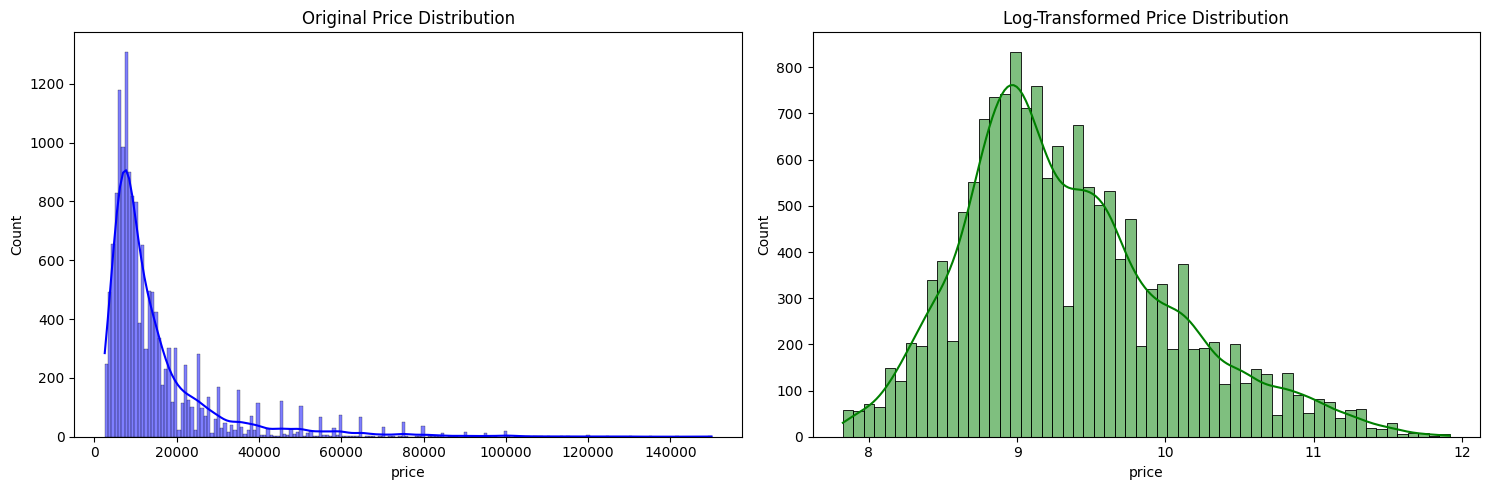

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# original price distribution
sns.histplot(df[target_col], kde=True, ax=axes[0], color='blue')
axes[0].set_title("Original Price Distribution")

# Log-Transformed Price distribution
sns.histplot(np.log1p(df[target_col]), kde=True, ax=axes[1], color='green')
axes[1].set_title("Log-Transformed Price Distribution")

plt.tight_layout()
plt.show()

### One Hot Encode Type column

In [63]:
df['type'] = df['type'].astype('category')
df_encoded = pd.get_dummies(df, columns=['type'], drop_first=True)

In [64]:
df_encoded

,bedrooms,bathrooms,parking,floor_size,suburb_avg_rent,city_avg_rent,muni_avg_rent,is_estate,has_security,is_modern,is_luxury,price,type_House,type_Townhouse
0,1.0,1.0,4.0,46.0,7867.619048,14570.621769,14358.133881,0,0,1,0,6250.0,False,False
1,2.0,1.0,4.0,46.0,7867.619048,14570.621769,14358.133881,0,0,0,0,7350.0,False,False
2,2.0,1.0,3.0,64.0,7867.619048,14570.621769,14358.133881,0,0,0,0,7350.0,False,False
3,3.0,3.0,2.0,300.0,7867.619048,14570.621769,14358.133881,1,1,0,0,13000.0,True,False
4,3.0,2.0,1.0,250.0,7867.619048,14570.621769,14358.133881,0,0,1,0,9800.0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17077,3.0,3.0,4.0,500.0,13224.800000,8698.700000,14358.133881,1,1,1,0,15000.0,True,False
17078,3.0,2.5,3.0,300.0,13224.800000,8698.700000,14358.133881,0,0,0,0,9400.0,False,True
17079,5.0,4.0,2.0,300.0,13224.800000,8698.700000,14358.133881,0,0,0,0,17070.0,True,False
17080,3.0,2.0,4.0,300.0,13224.800000,8698.700000,14358.133881,1,1,0,0,11000.0,True,False


In [65]:
def evaluate_model(name, model, X_test, y_test, best_params, log=False):
    preds = np.expm1(model.predict(X_test)) if log else model.predict(X_test)

    rmse = float(np.sqrt(mean_squared_error(y_test, preds)))
    mae = float(mean_absolute_error(y_test, preds))
    r2 = float(r2_score(y_test, preds))

    print(f"---- {name} ----")
    print(f"MAE:    {mae}\nRMSE:    {rmse}\nR2:    {r2}")
    print(f"Best parameters:\n{best_params}")

    return {
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        **best_params
    }


In [16]:
results = []

In [66]:
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=config["model"]["test_size"],
    random_state=config["model"]['random_state']
)

### Random forest training

In [23]:
from scipy.stats import randint

print(randint(2,50))

In [31]:
from scipy.stats import randint

param_dist = {
    'n_estimators':randint(10,500),
    'max_depth':[None, 10, 20, 30, 40, 50],
    'max_features':[0.1, 0.3, 0.5, 'sqrt', 'log2', None],
    'min_samples_leaf':[1,2,4,8],
    'min_samples_split':[2, 5, 10, 15, 20],
    'criterion':['squared_error','absolute_error','poisson','friedman_mse']
}
base_rf = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    base_rf,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, np.log1p(y_train))

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['squared_error', 'absolute_error', ...], 'max_depth': [None, 10, ...], 'max_features': [0.1, 0.3, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-vali

In [32]:
best_params = random_search.best_params_
best_rf = random_search.best_estimator_

In [36]:
results.append(evaluate_model("neg_mean_squared_error - log - wide search",best_rf,X_test,y_test,best_params,log=True))

---- neg_mean_squared_error - log - wide search ----
MAE:    3040.0153627133386
RMSE:    5564.773381170931
R2:    0.8502930150192045
Best parameters:
{'criterion': 'poisson', 'max_depth': 40, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 252}


In [39]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators':[230,240,250,260,270],
    'max_depth':[None, 35, 38, 39, 40, 41,42, 45],
    'max_features':['sqrt'],
    'min_samples_leaf':[1,2],
    'min_samples_split':[8, 10, 12],
    'criterion':['poisson']
}

grid_search = GridSearchCV(
    base_rf,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, np.log1p(y_train))

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['poisson'], 'max_depth': [None, 35, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [40]:
best_params = grid_search.best_params_
best_rf = grid_search.best_estimator_
results.append(evaluate_model("neg_mean_squared_error - log - grid search",best_rf,X_test,y_test,best_params,log=True))

---- neg_mean_squared_error - log - grid search ----
MAE:    3005.1156616685153
RMSE:    5478.086479143144
R2:    0.8549208955769676
Best parameters:
{'criterion': 'poisson', 'max_depth': 35, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 270}


In [42]:
data = pd.DataFrame(results)

In [43]:
data

,model,MAE,RMSE,R2,criterion,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators
0,Random Forest - wide search,3021.156851,5354.394462,0.861399,poisson,40.0,sqrt,1,10,252
1,neg_mean_absolute_error - wide search,2969.594764,5313.299305,0.863518,friedman_mse,NaN,0.5,1,5,139
2,neg_mean_squared_error - log - wide search,15163.668034,20899.043350,-1.111543,poisson,40.0,sqrt,1,10,252
3,neg_mean_squared_error - log - wide search,15163.668034,20899.043350,-1.111543,poisson,40.0,sqrt,1,10,252
4,neg_mean_squared_error - log - wide search,3040.015363,5564.773381,0.850293,poisson,40.0,sqrt,1,10,252
5,neg_mean_squared_error - grid search,3019.337493,5348.191197,0.861719,poisson,35.0,sqrt,1,10,230
6,neg_mean_squared_error - log - grid search,3005.115662,5478.086479,0.854921,poisson,35.0,sqrt,1,8,270


In [45]:
test = results.copy()

In [47]:
test.pop(2)

{'model': 'neg_mean_squared_error - log - wide search',
 'MAE': 15163.668034155982,
 'RMSE': 20899.043349742155,
 'R2': -1.111542911848641,
 'criterion': 'poisson',
 'max_depth': 40,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'n_estimators': 252}

In [51]:
test[0]['model'] = 'neg_mean_squared_error - wide search'

In [52]:
pd.DataFrame(test)

,model,MAE,RMSE,R2,criterion,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators
0,neg_mean_squared_error - wide search,3021.156851,5354.394462,0.861399,poisson,40.0,sqrt,1,10,252
1,neg_mean_absolute_error - wide search,2969.594764,5313.299305,0.863518,friedman_mse,NaN,0.5,1,5,139
2,neg_mean_squared_error - log - wide search,3040.015363,5564.773381,0.850293,poisson,40.0,sqrt,1,10,252
3,neg_mean_squared_error - grid search,3019.337493,5348.191197,0.861719,poisson,35.0,sqrt,1,10,230
4,neg_mean_squared_error - log - grid search,3005.115662,5478.086479,0.854921,poisson,35.0,sqrt,1,8,270


In [53]:
print(test)

[{'model': 'neg_mean_squared_error - wide search', 'MAE': 3021.156850603447, 'RMSE': 5354.394461665078, 'R2': 0.8613985340381567, 'criterion': 'poisson', 'max_depth': 40, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 252}, {'model': 'neg_mean_absolute_error - wide search', 'MAE': 2969.5947636616866, 'RMSE': 5313.29930459275, 'R2': 0.8635179113603443, 'criterion': 'friedman_mse', 'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 139}, {'model': 'neg_mean_squared_error - log - wide search', 'MAE': 3040.0153627133386, 'RMSE': 5564.773381170931, 'R2': 0.8502930150192045, 'criterion': 'poisson', 'max_depth': 40, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 252}, {'model': 'neg_mean_squared_error - grid search', 'MAE': 3019.33749260635, 'RMSE': 5348.19119715948, 'R2': 0.8617194978804634, 'criterion': 'poisson', 'max_depth': 35, 'max_features': 'sqrt', 'min

In [67]:
params = config["model"]["prod_params"]
regressor = RandomForestRegressor(
    **params, 
    random_state=42, 
    n_jobs=-1)

regressor.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",230
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'poisson'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",35
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [68]:
test.append(evaluate_model('prod_model',regressor,X_test,y_test,params))

---- prod_model ----
MAE:    3019.33749260635
RMSE:    5348.19119715948
R2:    0.8617194978804634
Best parameters:
{'n_estimators': 230, 'max_depth': 35, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'criterion': 'poisson'}


In [69]:
pd.DataFrame(test)

,model,MAE,RMSE,R2,criterion,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators
0,neg_mean_squared_error - wide search,3021.156851,5354.394462,0.861399,poisson,40.0,sqrt,1,10,252
1,neg_mean_absolute_error - wide search,2969.594764,5313.299305,0.863518,friedman_mse,NaN,0.5,1,5,139
2,neg_mean_squared_error - log - wide search,3040.015363,5564.773381,0.850293,poisson,40.0,sqrt,1,10,252
3,neg_mean_squared_error - grid search,3019.337493,5348.191197,0.861719,poisson,35.0,sqrt,1,10,230
4,neg_mean_squared_error - log - grid search,3005.115662,5478.086479,0.854921,poisson,35.0,sqrt,1,8,270
5,prod_model,3019.337493,5348.191197,0.861719,poisson,35.0,sqrt,1,10,230


In [70]:
with open("../configs/test.yaml", 'w') as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

In [71]:
with open("../configs/model_config.yaml", "r") as f:
    test =  yaml.safe_load(f)

test

{'param_dist': {'n_estimators': [200, 230, 250, 270, 300, 350, 400],
  'max_depth': [30, 35, 40, 45, None],
  'max_features': ['sqrt', 0.4, 0.5],
  'min_samples_leaf': [1, 2],
  'min_samples_split': [5, 8, 10, 12],
  'criterion': ['poisson', 'friedman_mse']},
 'model': {'type': 'random_forest',
  'version': 1,
  'random_state': 42,
  'test_size': 0.2,
  'prod_params': {'n_estimators': 230,
   'max_depth': 35,
   'max_features': 'sqrt',
   'min_samples_leaf': 1,
   'min_samples_split': 10,
   'criterion': 'poisson'},
  'production_metrics': {'rmse': 5348.19, 'r2': 0.8617, 'mae': 3019.33}},
 'features': {'numerical': ['bedrooms',
   'bathrooms',
   'parking',
   'floor_size',
   'suburb_avg_rent',
   'city_avg_rent',
   'muni_avg_rent',
   'is_estate',
   'has_security',
   'is_modern',
   'is_luxury'],
  'categorical': ['type']},
 'target': 'price'}